# 03 - Sentiment Analysis

Distribution and breakdown of sentiment scores across stances, councils and planning application types.


In [1]:
import sys
sys.path.append("../functions")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import DATA_DIR, FIGURES_DIR, STANCE_PALETTE

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_DIR / "comments.csv")
print(f"Loaded {len(df):,} comments")
df.groupby("stance").size()

Loaded 30,393 comments


stance
Neutral       742
Objects     27413
Supports     2238
dtype: int64

## Overall sentiment distribution

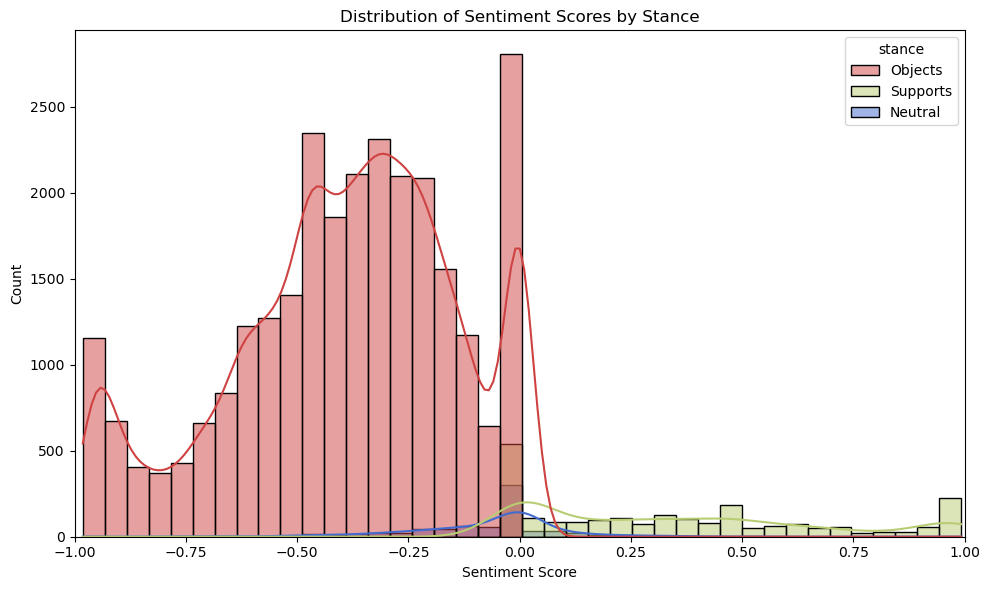

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x="sentiment_score", bins=40, kde=True,
             hue="stance", palette=STANCE_PALETTE, ax=ax)
ax.set_xlim(-1, 1)
ax.set_xlabel("Sentiment Score")
ax.set_title("Distribution of Sentiment Scores by Stance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment & stance by council

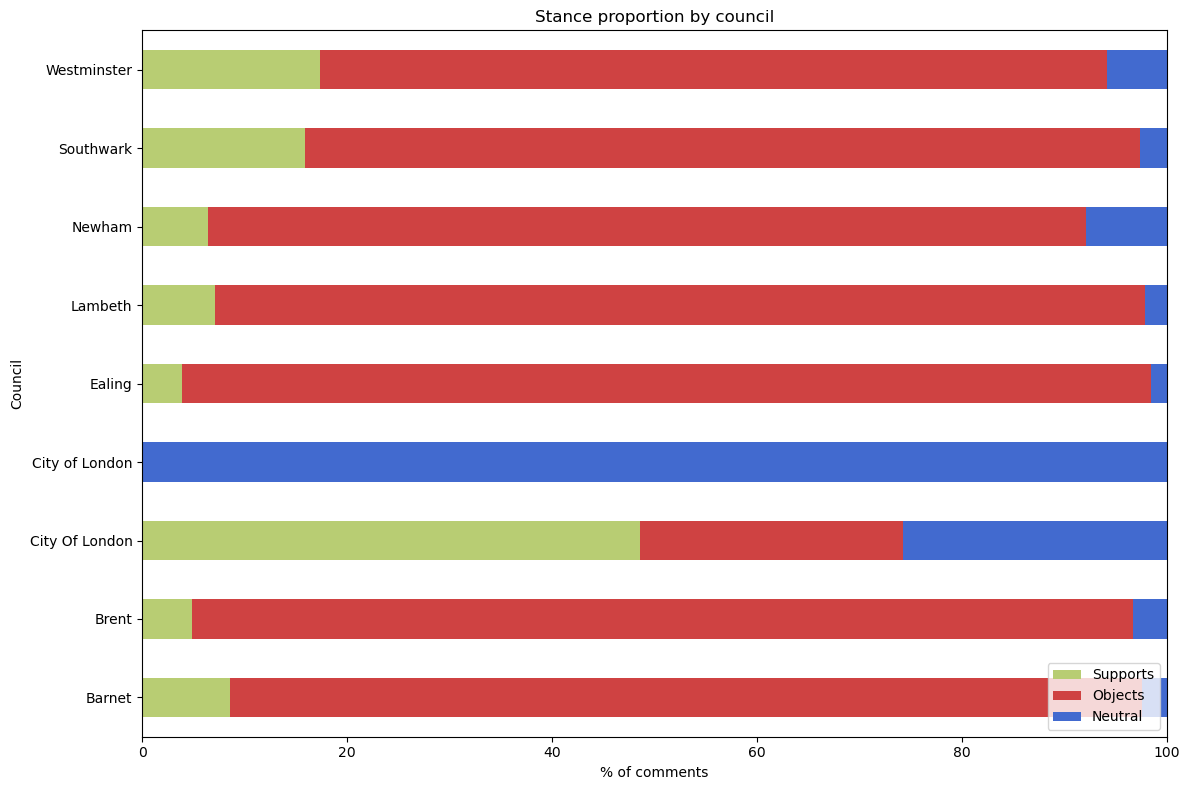

In [4]:
# Stacked bar: stance proportions per council
stance_pct = (
    df.groupby(["council", "stance"]).size()
    .unstack(fill_value=0)
    [["Supports", "Objects", "Neutral"]]
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
)

fig, ax = plt.subplots(figsize=(12, 8))
stance_pct.plot.barh(
    ax=ax, stacked=True,
    color=[STANCE_PALETTE[s] for s in stance_pct.columns],
)
ax.set_xlim(0, 100)
ax.set_xlabel("% of comments")
ax.set_ylabel("Council")
ax.set_title("Stance proportion by council")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "stance_by_council.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment score histograms by council

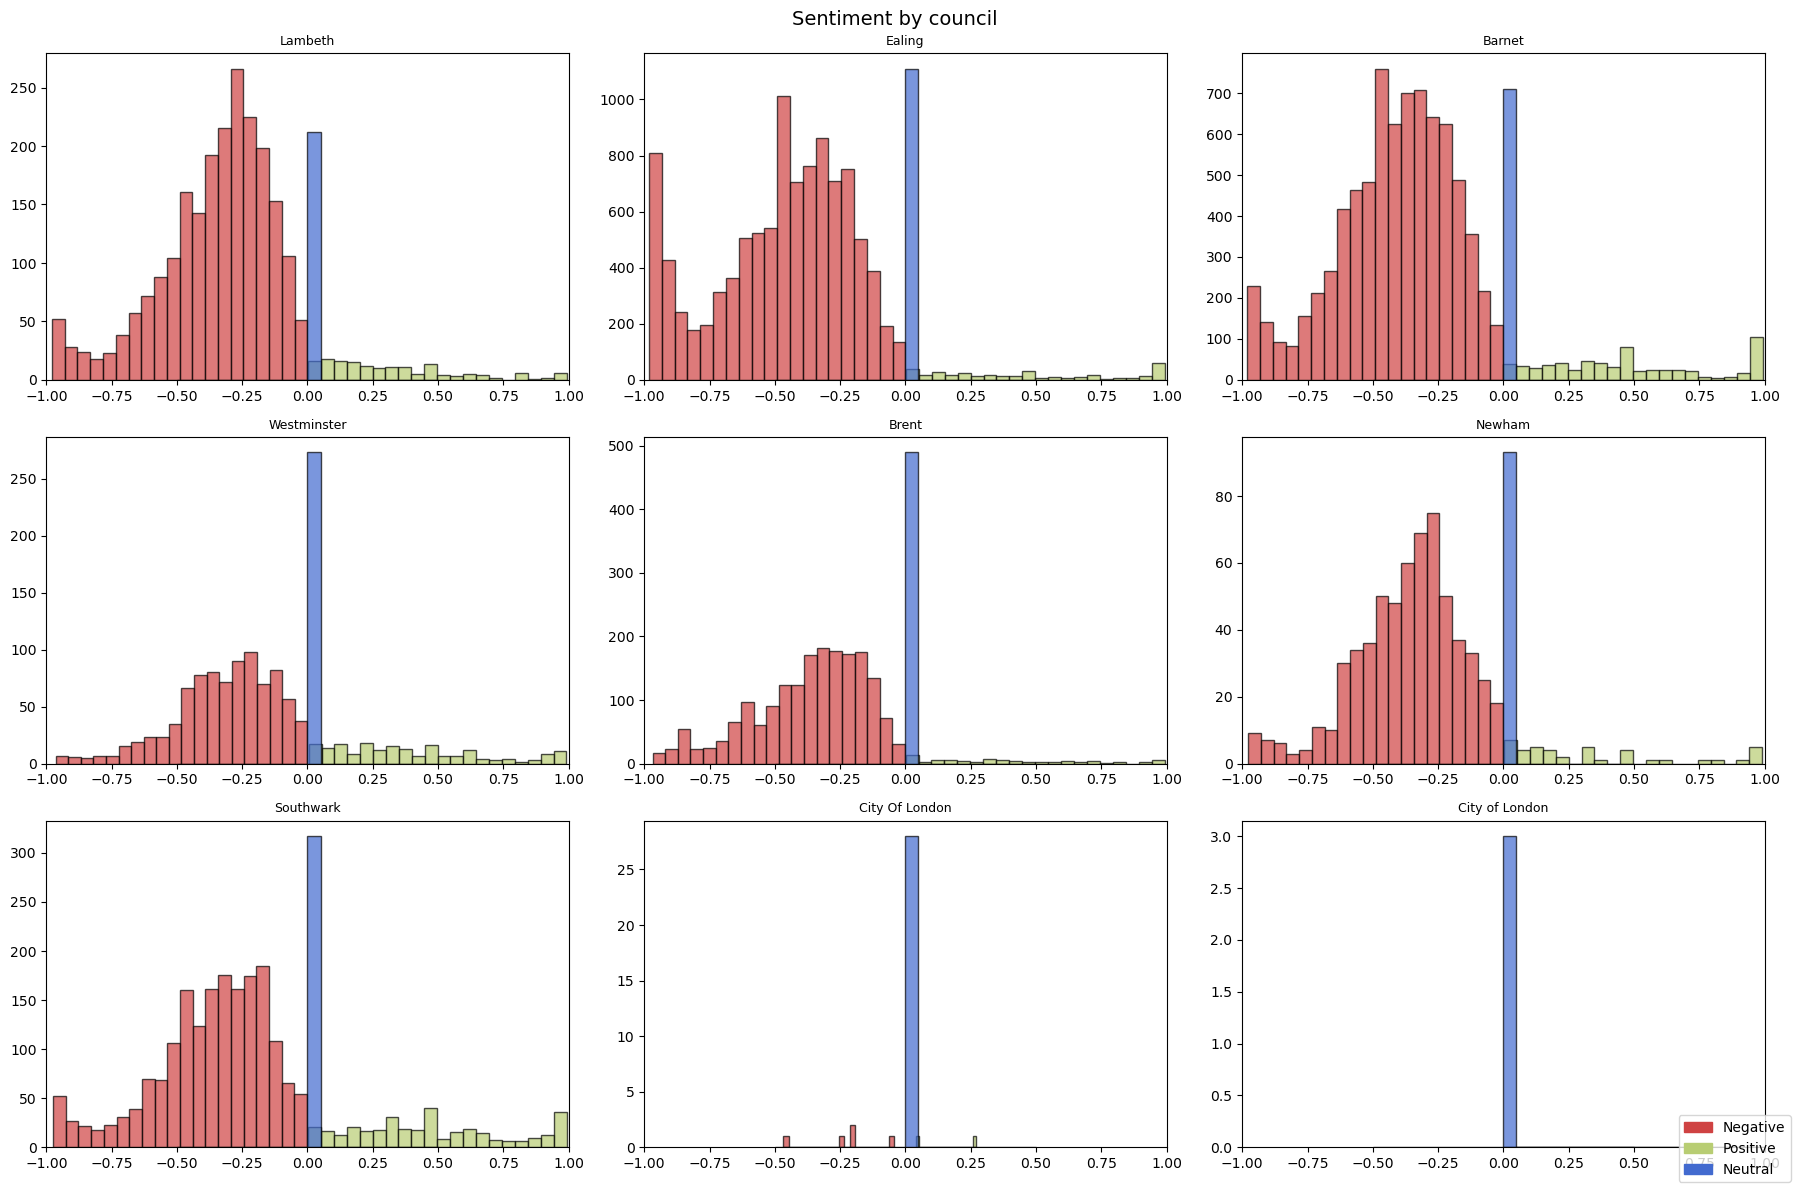

In [5]:
councils = df["council"].unique()
cols  = 3
rows  = math.ceil(len(councils) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for ax, council in zip(axes, councils):
    sub = df[df["council"] == council]["sentiment_score"].dropna()
    neg = sub[sub < 0]
    pos = sub[sub > 0]
    neu = sub[sub == 0]
    ax.hist(neg, bins=20, color=STANCE_PALETTE["Objects"], edgecolor='black', alpha=0.7, label="Negative")
    ax.hist(pos, bins=20, color=STANCE_PALETTE["Supports"], edgecolor='black', alpha=0.7, label="Positive")
    ax.hist(neu, bins=20, color=STANCE_PALETTE["Neutral"], edgecolor='black', alpha=0.7, label="Neutral")
    ax.set_title(council, fontsize=9)
    ax.set_xlim(-1, 1)

for ax in axes[len(councils):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=STANCE_PALETTE["Objects"]),
           plt.Rectangle((0,0),1,1, color=STANCE_PALETTE["Supports"]),
           plt.Rectangle((0,0),1,1, color=STANCE_PALETTE["Neutral"])]
fig.legend(handles, ["Negative", "Positive", "Neutral"], loc="lower right")
plt.suptitle("Sentiment by council", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_by_council.png", dpi=150, bbox_inches="tight")
plt.show()
